# A 1D log-normal environment field for the bias layer — prototype
the current BIAS layer
(`cpp/lensing.cpp::deltaNhfNFW`, l.123) draws an **independent** log-normal count modulation per
$(j_z, j_M)$ grid cell with amplitude $\sigma_b = D_g(z)\,b(M,z)\,\sigma(M_b)$, where $M_b$ is the
grid cell's tube-segment mass. Neighbouring cells have no memory of each other, and refining the
grid ($N_z\!\uparrow$, $\kappa_{\rm thr}\!\uparrow$) makes the draws wilder — no continuum limit.

**This notebook prototypes the replacement**: ONE correlated
Gaussian field $\delta_{\rm 1D}(x)$ along the LOS, from which every cell reads its environment.

$$P_{\rm 1D}(k_\parallel) = \frac{1}{2\pi}\int_{k_\parallel}^{\infty}\!\mathrm{d}k\,k\,P(k)\,
\tilde W^2\!\left(R_\perp\sqrt{k^2-k_\parallel^2}\right)
\qquad\text{(Kaiser & Peacock 1991, eq. 3.8)}$$

$$\delta_{\rm 1D}(x) = \frac{1}{L}\sum_{n\ge1}\tilde\delta_n e^{ik_n x} + \mathrm{c.c.},\quad
k_n = \frac{2\pi n}{L},\qquad
\mathrm{Re}\,\tilde\delta_n,\ \mathrm{Im}\,\tilde\delta_n \sim \mathcal N(0, \sigma_n^2),\quad
\sigma_n^2 = \frac{L}{2}P_{\rm 1D}(k_n)$$

$$n(x, M, z) = \bar n(M,z)\, e^{\,b(M,z)\,\delta_{\rm 1D}(x) - \frac12 b(M,z)^2\sigma_{\rm 1D}^2},
\qquad \sigma_{\rm 1D}^2 = \frac1\pi\int_0^\infty\!P_{\rm 1D}\,\mathrm{d}k_\parallel,$$

with $b(M,z)$ absorbing the linear growth $D(z)$ (lightcone approximation, as in log-normal galaxy
mocks — Agrawal et al. 2017; Coles & Jones 1991).

**The two knobs this notebook is for:**
1. **Periodicity / padding** — the mode sum makes $\delta_{\rm 1D}$ periodic with period $L$.
   How much padding $L = {\rm pad}\times\chi(z_s)$ do we need? (§C)
2. **$R_\perp$** — the transverse window scale sets the point variance $\sigma_{\rm 1D}^2$;
   it is the one physical scale of the model (peak–background split). (§A, §D)

Cosmology/P(k) comes from the validated Python port in
`scripts/convergence/bias_field_prototype.py` (checked vs `gwlensing` helpers ≤5e-9, 2026-07-14).
Units: **comoving kpc** everywhere; $k$ in kpc$^{-1}$.

In [40]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def find_repo():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "CLAUDE.md").exists() and (p / "scripts").exists():
            return p
    raise FileNotFoundError("run this notebook from inside the gw-wl-emulator repo")

REPO = find_repo()
sys.path.insert(0, str(REPO / "scripts" / "convergence"))
from bias_field_prototype import Cosmo   # validated port of cpp/cosmology

# Bessel J1: scipy if available, else Abramowitz–Stegun 9.4 polynomial (|err|<4e-8)
try:
    from scipy.special import j1 as _j1
except ImportError:
    def _j1(x):
        x = np.asarray(x, float); ax = np.abs(x)
        small = ax < 8.0
        y = np.where(small, x * x, 0.0)
        p1 = x * (72362614232.0 + y * (-7895059235.0 + y * (242396853.1
             + y * (-2972611.439 + y * (15704.48260 + y * (-30.16036606))))))
        q1 = 144725228442.0 + y * (2300535178.0 + y * (18583304.74
             + y * (99447.43394 + y * (376.9991397 + y))))
        z = np.where(~small, 8.0 / np.where(ax == 0, 1.0, ax), 0.0)
        y2 = z * z
        p2 = 1.0 + y2 * (0.183105e-2 + y2 * (-0.3516396496e-4
             + y2 * (0.2457520174e-5 + y2 * (-0.240337019e-6))))
        q2 = 0.04687499995 + y2 * (-0.2002690873e-3 + y2 * (0.8449199096e-5
             + y2 * (-0.88228987e-6 + y2 * 0.105787412e-6)))
        xx = ax - 2.356194491
        big = np.sqrt(0.636619772 / np.where(ax == 0, 1.0, ax)) * (
            np.cos(xx) * p2 - z * np.sin(xx) * q2)
        return np.where(small, p1 / q1, np.sign(x) * big)

from math import erfc
Phic = np.vectorize(lambda x: 0.5 * erfc(x / np.sqrt(2.0)))  # P(N(0,1) > x)

def Wdisk(x):
    '''2D tophat (disk) window: Wtilde(x) = 2 J1(x)/x, Wtilde(0) = 1.'''
    x = np.asarray(x, float)
    return np.where(x < 1e-8, 1.0 - x * x / 8.0,
                    2.0 * _j1(np.where(x < 1e-8, 1.0, x)) / np.where(x < 1e-8, 1.0, x))

In [41]:
class P1D:
    """P_1D(kpar; Rperp) — KP91 projection of the code's own linear P(k), z=0.

    Exact integral tabulated once on a log-kpar grid; __call__ interpolates
    log-log, so evaluating ~1e5 mode wavenumbers is free.
    """

    def __init__(self, C, Rperp, nkperp=2048, nkpar=1200, kperp_max_fac=60.0):
        self.C, self.R = C, float(Rperp)
        kp_max = kperp_max_fac / max(self.R, 10.0)   # window kills kperp >~ few/R
        kperp = np.exp(np.linspace(np.log(1e-9), np.log(kp_max), nkperp))
        dlnkp = np.log(kperp[1] / kperp[0])
        self.kpar_tab = np.exp(np.linspace(np.log(1e-9), np.log(kp_max), nkpar))
        W2 = Wdisk(kperp * self.R) ** 2
        out = np.empty(nkpar)
        for i0 in range(0, nkpar, 128):              # chunked: memory-safe
            i1 = min(i0 + 128, nkpar)
            kk = np.sqrt(self.kpar_tab[None, i0:i1] ** 2 + kperp[:, None] ** 2)
            out[i0:i1] = np.trapezoid(kperp[:, None] ** 2 * C.Pk(kk) * W2[:, None],
                                      dx=dlnkp, axis=0) / (2.0 * np.pi)
        self.P_tab = out
        self._lk, self._lP = np.log(self.kpar_tab), np.log(out)

    def __call__(self, kpar):
        kpar = np.asarray(kpar, float)
        return np.exp(np.interp(np.log(np.clip(kpar, self.kpar_tab[0], None)),
                                self._lk, self._lP, right=-np.inf))

    def sigma2(self):
        """sigma_1D^2 = (1/pi) int_0^inf P_1D dkpar."""
        return float(np.trapezoid(self.P_tab * self.kpar_tab,
                                  dx=self._lk[1] - self._lk[0]) / np.pi)

    def sigma2_seg(self, Dchi):
        """Variance of the segment-average over length Dchi (sinc^2 window)."""
        k = self.kpar_tab
        snc = np.sinc(np.outer(np.atleast_1d(Dchi), k) / (2.0 * np.pi)) ** 2
        return np.trapezoid(snc * (self.P_tab * k)[None, :],
                            dx=self._lk[1] - self._lk[0], axis=1) / np.pi

    def xi(self, dchi):
        """xi_1D(dchi), continuum. NOTE: log-grid quadrature -> trust only for
        dchi <~ 100 Mpc; at larger lags use Field1D.xi_periodic of a big-pad
        field (linear k grid resolves the cos oscillations)."""
        k, P = self.kpar_tab, self.P_tab
        dchi = np.atleast_1d(np.asarray(dchi, float))
        return np.trapezoid(P[None, :] * k[None, :]
                            * np.cos(k[None, :] * dchi[:, None]),
                            dx=self._lk[1] - self._lk[0], axis=1) / np.pi

In [32]:
class Field1D:
    """delta(x) = (1/L) sum_n dtilde_n e^{ik_n x} + c.c. on a periodic path L.

    sigma_n^2 = (L/2) P_1D(k_n) per Re/Im component. Modes are kept up to
    k_max = kmax_fac / Rperp — beyond that the disk window has killed P_1D
    (truncation error is reported as sigma2_disc / sigma2()).
    """

    def __init__(self, p1d, L, kmax_fac=15.0, Nmax=100_000):
        self.L = float(L)
        kmax = kmax_fac / max(p1d.R, 10.0)
        self.N = min(int(np.ceil(kmax * self.L / (2.0 * np.pi))), Nmax)
        self.k = 2.0 * np.pi * np.arange(1, self.N + 1) / self.L
        self.P = p1d(self.k)
        self.sig_n = np.sqrt(self.L * self.P / 2.0)
        self.sigma2_disc = float(np.sum(2.0 * self.P / self.L))

    def draw_modes(self, rng, nreal=1):
        return (rng.normal(0.0, self.sig_n, size=(nreal, self.N))
                + 1j * rng.normal(0.0, self.sig_n, size=(nreal, self.N)))

    def evaluate(self, modes, x):
        """Direct mode sum at arbitrary x (the whiteboard formula, verbatim)."""
        ph = np.exp(1j * np.outer(self.k, np.asarray(x, float)))
        return (2.0 / self.L) * np.real(modes @ ph)

    def evaluate_fft(self, modes, ngrid=None):
        """Same field on a uniform grid x_j = j L/ngrid via irfft (fast path)."""
        if ngrid is None:
            ngrid = 1 << int(np.ceil(np.log2(2 * self.N + 2)))
        assert ngrid // 2 - 1 >= self.N, "ngrid too small: modes would be dropped"
        spec = np.zeros((modes.shape[0], ngrid // 2 + 1), complex)
        spec[:, 1:self.N + 1] = modes
        return (ngrid / self.L) * np.fft.irfft(spec, n=ngrid, axis=1), ngrid

    def sample(self, rng, nreal, x=None, chunk=100):
        """nreal realizations at x (or the FFT grid), memory-safe chunks."""
        out = []
        for s0 in range(0, nreal, chunk):
            m = self.draw_modes(rng, min(chunk, nreal - s0))
            d = self.evaluate(m, x) if x is not None else self.evaluate_fft(m)[0]
            out.append(d.astype(np.float32))
        return np.concatenate(out, axis=0)

    def xi_periodic(self, dchi):
        """EXACT xi of the periodic truncated field: (2/L) sum_n P_n cos(k_n dchi)."""
        dchi = np.atleast_1d(np.asarray(dchi, float))
        return (2.0 / self.L) * (np.cos(np.outer(dchi, self.k)) @ self.P)


def lognormal_lambda(b, delta, sigma2):
    """n/nbar = exp(b delta - b^2 sigma^2 / 2); <n> = nbar exactly (sigma^2 must
    be the variance of the delta actually used — point or segment-averaged)."""
    return np.exp(b * delta - 0.5 * b ** 2 * sigma2)

In [33]:
# ----------------------------- knobs to play with -----------------------------
ZS         = 5.0          # source redshift
RPERP      = 3000.0       # transverse window radius [comoving kpc] for §B/§C
RPERP_LIST = [100.0, 300.0, 1000.0, 3000.0, 10000.0, 30000.0]   # §A scan
PAD_LIST   = [1.0, 1.05, 1.1, 1.25, 1.5, 2.0, 4.0]              # §C scan
PAD        = 2.0          # default padding for §B
SEED       = 20260715

rng = np.random.default_rng(SEED)
C = Cosmo(Nz=100)                       # fiducial: Om=0.315, s8=0.811, h=0.674
chi_s = float(C.dc(ZS))
z_of_chi = lambda chi: np.interp(chi, C.dc_d, C.dc_z)
print(f"chi(z_s={ZS:g}) = {chi_s/1e6:.3f} Gpc comoving")

chi(z_s=5) = 7.944 Gpc comoving


## A. $P_{\rm 1D}$ and the $R_\perp$ decision

$R_\perp$ regulates KP91's small-scale leakage: every $k_\parallel$ receives power from ALL
transverse modes with $k_\perp \lesssim 1/R_\perp$. As $R_\perp\to0$ (bare pencil) the point
variance diverges for a CDM spectrum — some transverse scale is **unavoidable**; the question is
what sets it. The peak–background-split candidate is the halo's own Lagrangian radius
$R_L(M) = (3M/4\pi\bar\rho_m)^{1/3}$: fluctuations inside the patch that collapsed into the halo
are the halo, already counted by the HMF + Poisson draw.

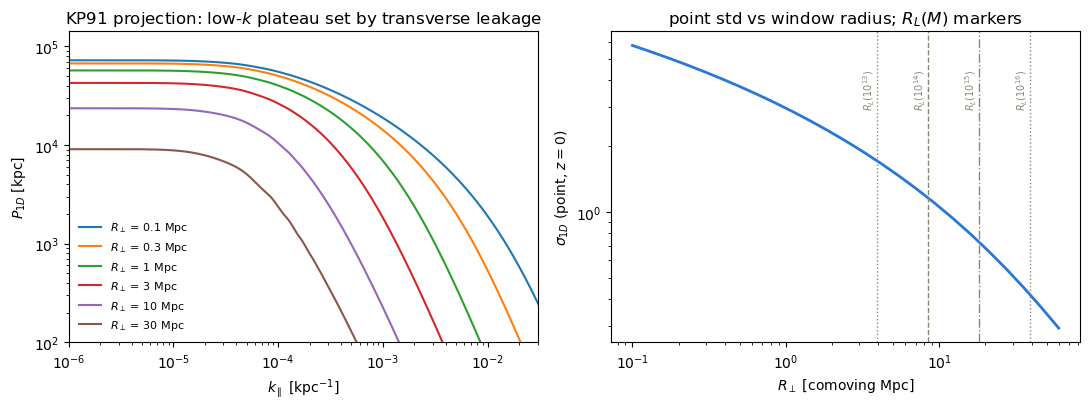

Rperp [Mpc]  sigma_1D   (times Dg(z=1) = 0.607 at z=1)
       0.1   5.7586
       0.3   4.3454
       1.0   2.9766
       3.0   1.9319
      10.0   1.0525
      30.0   0.5113


In [42]:
p1ds = {R: P1D(C, R) for R in RPERP_LIST}
sig1d = {R: np.sqrt(p1ds[R].sigma2()) for R in RPERP_LIST}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for R in RPERP_LIST:
    ax1.loglog(p1ds[R].kpar_tab, p1ds[R].P_tab, label=f"$R_\\perp$ = {R/1e3:g} Mpc")
ax1.set_xlim(1e-6, 3e-2); ax1.set_ylim(1e2, None)
ax1.set_xlabel("$k_\\parallel$ [kpc$^{-1}$]"); ax1.set_ylabel("$P_{1D}$ [kpc]")
ax1.set_title("KP91 projection: low-$k$ plateau set by transverse leakage")
ax1.legend(fontsize=8, frameon=False)

Rg = np.exp(np.linspace(np.log(100.0), np.log(60000.0), 25))
sg = [np.sqrt(P1D(C, R, nkperp=1024, nkpar=600).sigma2()) for R in Rg]
ax2.loglog(Rg / 1e3, sg, "-", color="#2a78d6", lw=2)
for M, ls in ((1e13, ":"), (1e14, "--"), (1e15, "-."), (1e16, ":")):
    RL = (3 * M / (4 * np.pi * C.rhoM0)) ** (1 / 3)
    ax2.axvline(RL / 1e3, color="#8a8776", ls=ls, lw=1)
    ax2.text(RL / 1e3, 4.5, f"$R_L(10^{{{int(np.log10(M))}}})$", rotation=90,
             fontsize=7, color="#8a8776", va="top", ha="right")
ax2.set_xlabel("$R_\\perp$ [comoving Mpc]"); ax2.set_ylabel("$\\sigma_{1D}$ (point, $z=0$)")
ax2.set_title("point std vs window radius; $R_L(M)$ markers")
plt.tight_layout(); plt.show()

print("Rperp [Mpc]  sigma_1D   (times Dg(z=1) = %.3f at z=1)" % C.Dg(1.0))
for R in RPERP_LIST:
    print(f"  {R/1e3:8.1f}   {sig1d[R]:.4f}")

**Read-off:** $\sigma_{\rm 1D}$(point, $z$=0) runs $\sim$5.8 → 0.5 over $R_\perp$ = 0.1 → 30 Mpc.
With the $R_L$ floor for cluster-mass halos ($10^{14}$–$10^{16}\,M_\odot$ → 8–39 Mpc comoving) the
top-mass bins live at $\sigma_{\rm 1D}\sim$ 0.4–1 — bounded, physical, and $\kappa_{\rm thr}$/grid
independent. Two design variants to bring to the supervisor:
- **one field** at fixed $R_\perp \approx R_L(M_{\rm max})$, all $M$ ride it via $b(M,z)$ (simplest, matches his write-up);
- **per-mass floor** $R_\perp = \max(R_{\rm cyl}, R_L(M))$ (strictly needs one field per $M$-band; only matters if the light bins' amplitude is ever tail-relevant).

## B. Generator + validation

Draw $\tilde\delta_n$, evaluate by direct mode sum AND by FFT (must agree to machine precision),
then check the measured $\langle\delta^2\rangle$ and $\xi_{\rm 1D}(\Delta\chi)$ against the
analytic targets. `xi_periodic` (the exact expectation of the truncated periodic sum) is the
honest reference; the continuum `xi()` differs at large lags by construction (finite $L$).

L = pad 2 x chi_s = 15.89 Gpc, N modes = 12643, sigma2_disc/cont = 0.9876 (deficit = missing k<2pi/L + k>kmax truncation)
FFT vs direct mode sum: max rel dev = 2.57e-12  (machine precision)


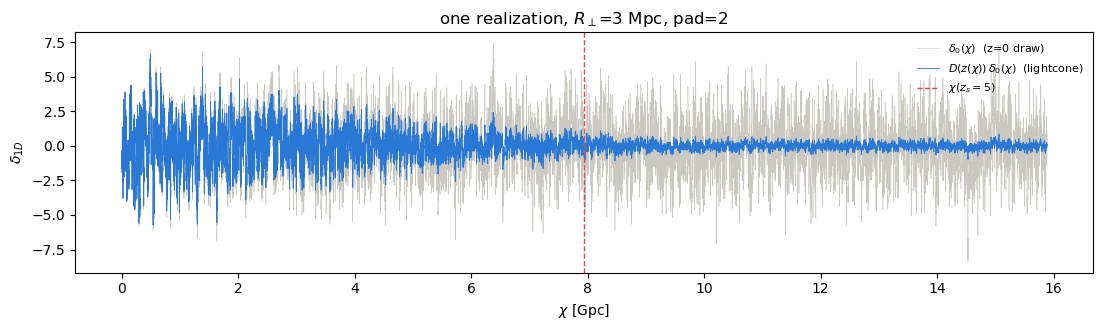

In [43]:
p = P1D(C, RPERP)
s2_cont = p.sigma2()
f = Field1D(p, PAD * chi_s)
print(f"L = pad {PAD:g} x chi_s = {f.L/1e6:.2f} Gpc, N modes = {f.N}, "
      f"sigma2_disc/cont = {f.sigma2_disc/s2_cont:.4f} "
      f"(deficit = missing k<2pi/L + k>kmax truncation)")

m = f.draw_modes(rng, 2)
d_fft, ng = f.evaluate_fft(m)
xg = np.arange(ng) * (f.L / ng)
sub = slice(0, ng, ng // 128)
dev = np.max(np.abs(d_fft[:, sub] - f.evaluate(m, xg[sub]))) / np.std(d_fft)
print(f"FFT vs direct mode sum: max rel dev = {dev:.2e}  (machine precision)")

# one lightcone realization: z=0 field and D(z(chi))-scaled field
d0 = d_fft[0]
grow = C.Dg(z_of_chi(xg))
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(xg / 1e6, d0, lw=0.4, alpha=0.45, color="#8a8776", label="$\\delta_0(\\chi)$  (z=0 draw)")
ax.plot(xg / 1e6, grow * d0, lw=0.6, color="#2a78d6",
        label="$D(z(\\chi))\\,\\delta_0(\\chi)$  (lightcone)")
ax.axvline(chi_s / 1e6, color="#e34948", ls="--", lw=1, label=f"$\\chi(z_s={ZS:g})$")
ax.set_xlabel("$\\chi$ [Gpc]"); ax.set_ylabel("$\\delta_{1D}$")
ax.set_title(f"one realization, $R_\\perp$={RPERP/1e3:g} Mpc, pad={PAD:g}")
ax.legend(fontsize=8, frameon=False, loc="upper right")
plt.tight_layout(); plt.show()

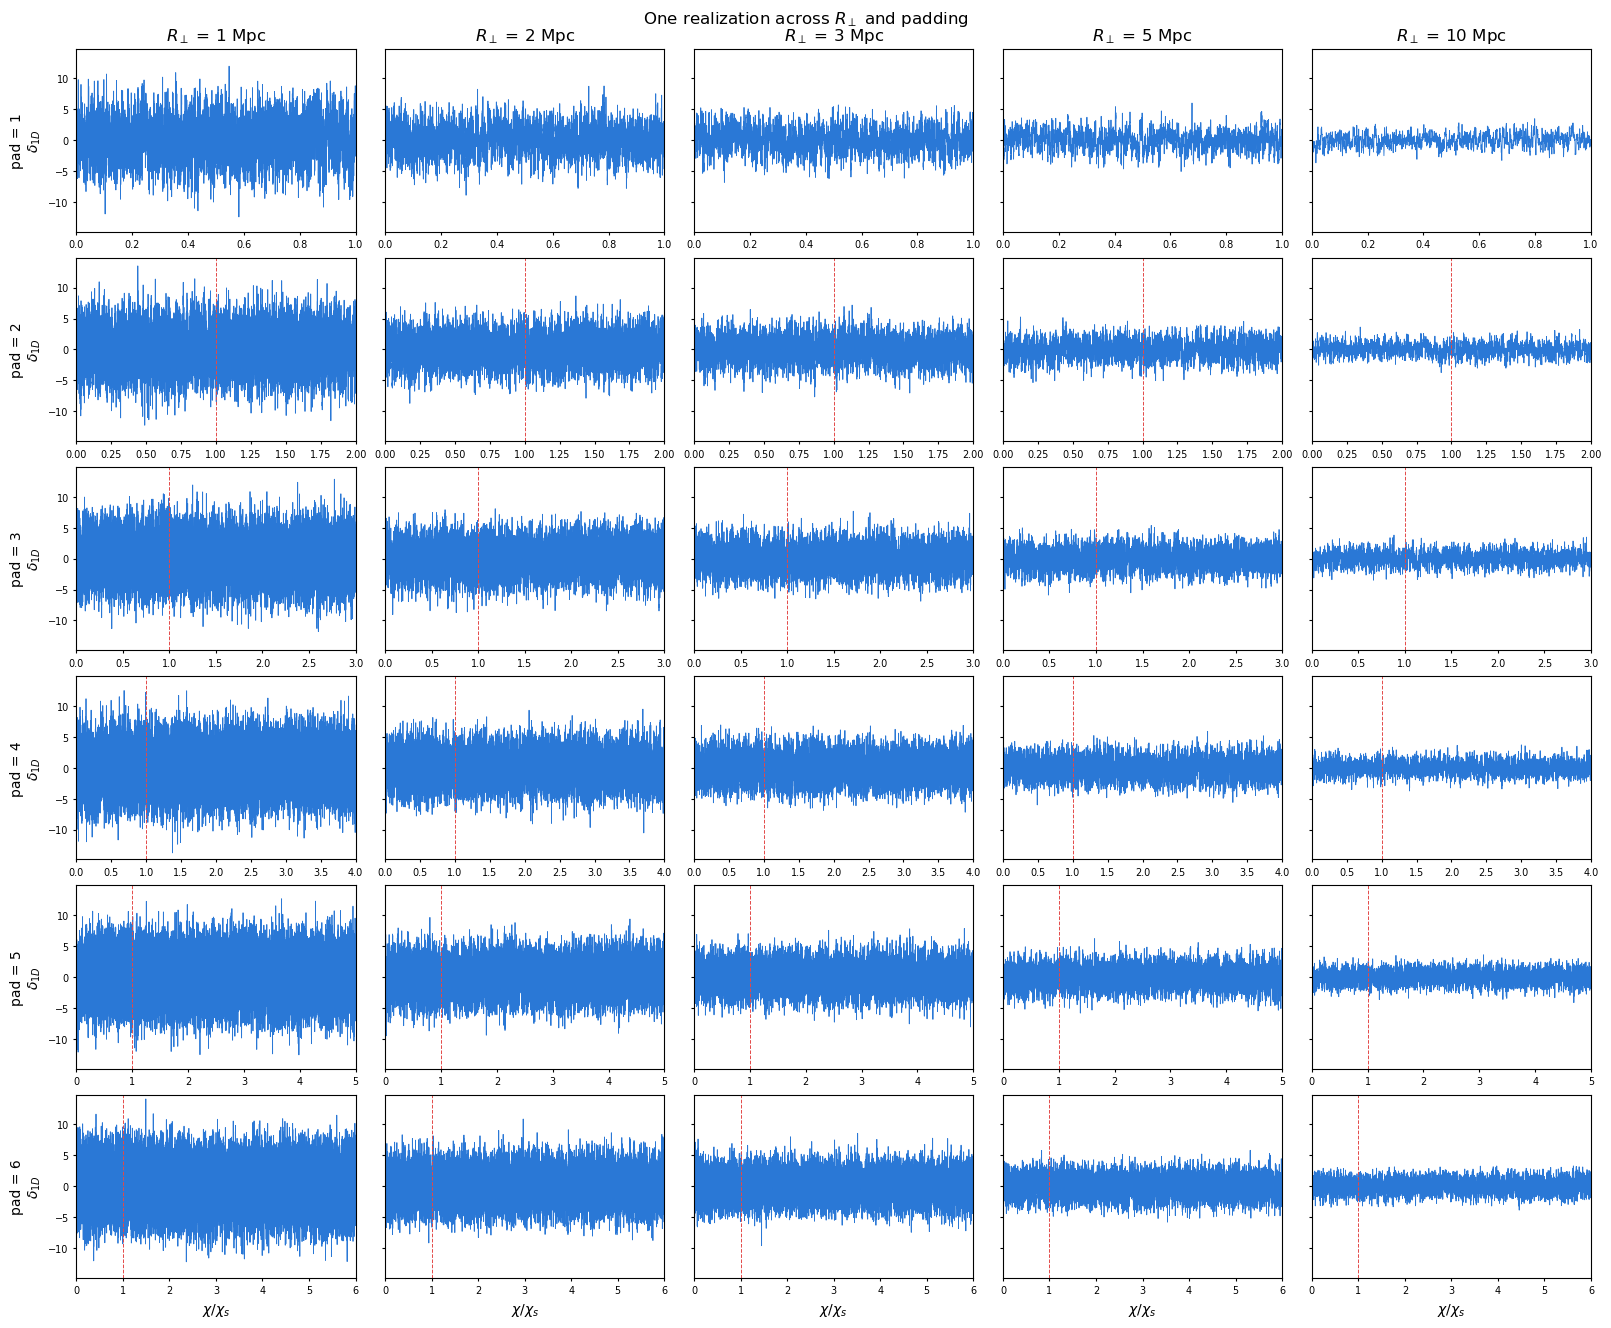

In [53]:
# Coarse sweep for display only: R_perp = 1..10 Mpc, pad = 1..6
RPERP_SWEEP = np.array([1.0, 2.0, 3.0, 5.0, 10.0], dtype=float) * 1e3  # kpc
PAD_SWEEP = np.arange(1.0, 7.0, 1.0)
BASE_SEED = 20260715

samples = []
ymax = 0.0
for i, pad in enumerate(PAD_SWEEP):
    row = []
    for j, R in enumerate(RPERP_SWEEP):
        p_loc = P1D(C, R, nkperp=256, nkpar=240)
        f_loc = Field1D(p_loc, pad * chi_s, kmax_fac=8.0)
        rng_loc = np.random.default_rng(BASE_SEED + 100 * i + j)
        modes = f_loc.draw_modes(rng_loc, 1)
        d_fft, ng = f_loc.evaluate_fft(modes)
        xg = np.arange(ng) * (f_loc.L / ng)
        keep = xg <= f_loc.L
        xplot = xg[keep] / chi_s
        yplot = d_fft[0, keep]
        ymax = max(ymax, float(np.max(np.abs(yplot))))
        row.append((xplot, yplot))
    samples.append(row)

ylim = 1.05 * ymax if ymax > 0 else 1.0
fig, axes = plt.subplots(
    len(PAD_SWEEP), len(RPERP_SWEEP),
    figsize=(16, 13), sharex=False, sharey=True, constrained_layout=True,
)

for i, pad in enumerate(PAD_SWEEP):
    for j, R in enumerate(RPERP_SWEEP):
        ax = axes[i, j]
        xplot, yplot = samples[i][j]
        ax.plot(xplot, yplot, lw=0.6, color="#2a78d6")
        ax.axvline(1.0, color="#e34948", ls="--", lw=0.7)
        ax.set_xlim(0.0, pad)
        ax.set_ylim(-ylim, ylim)
        if i == 0:
            ax.set_title(f"$R_\\perp$ = {R / 1e3:g} Mpc")
        if j == 0:
            ax.set_ylabel(f"pad = {pad:g}\n$\\delta_{{1D}}$")
        if i == len(PAD_SWEEP) - 1:
            ax.set_xlabel("$\\chi / \\chi_s$")
        ax.tick_params(labelsize=7, length=2)

fig.suptitle("One realization across $R_\\perp$ and padding", y=1.01)
plt.show()

measured <delta^2> = 3.6808  vs analytic (discrete) 3.6858  ratio 0.9986


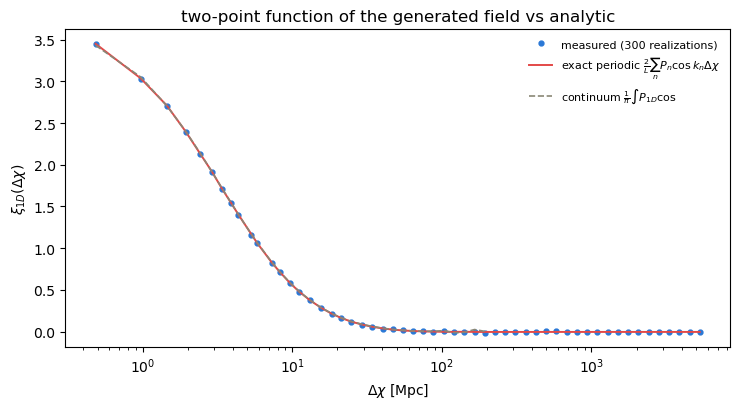

In [44]:
NREAL = 300
d = f.sample(rng, NREAL)
var_meas = float(np.mean(d.astype(np.float64) ** 2))
print(f"measured <delta^2> = {var_meas:.4f}  vs analytic (discrete) "
      f"{f.sigma2_disc:.4f}  ratio {var_meas/f.sigma2_disc:.4f}")

spec = np.fft.rfft(d.astype(np.float64), axis=1)
ngm = d.shape[1]
ac = np.fft.irfft(np.abs(spec) ** 2, n=ngm, axis=1).mean(axis=0) / ngm

lag = np.unique(np.round(np.exp(np.linspace(0, np.log(ngm // 3), 60))).astype(int))
dchi = lag * (f.L / ngm)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(dchi / 1e3, ac[lag], "o", ms=3.5, color="#2a78d6",
        label=f"measured ({NREAL} realizations)")
ax.plot(dchi / 1e3, f.xi_periodic(dchi), "-", color="#e34948", lw=1.4,
        label="exact periodic $\\frac{2}{L}\\sum_n P_n\\cos k_n\\Delta\\chi$")
sm = dchi < 2e5
ax.plot(dchi[sm] / 1e3, p.xi(dchi[sm]), "--", color="#8a8776", lw=1.2,
        label="continuum $\\frac{1}{\\pi}\\int P_{1D}\\cos$")
ax.set_xscale("log"); ax.set_xlabel("$\\Delta\\chi$ [Mpc]")
ax.set_ylabel("$\\xi_{1D}(\\Delta\\chi)$")
ax.set_title("two-point function of the generated field vs analytic")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## C. Periodicity — how much padding?

The $+{\rm c.c.}$ sum makes $\delta_{\rm 1D}$ periodic with period $L$. With $L = \chi(z_s)$
exactly, the observer end and the source end are THE SAME POINT of the field
(corr $= +1$) — maximal spurious correlation across the whole path. The experiment: correlation
between $\delta(0)$ and $\delta(\chi_s)$ vs padding, plus the shape of $\xi$ near the wrap.

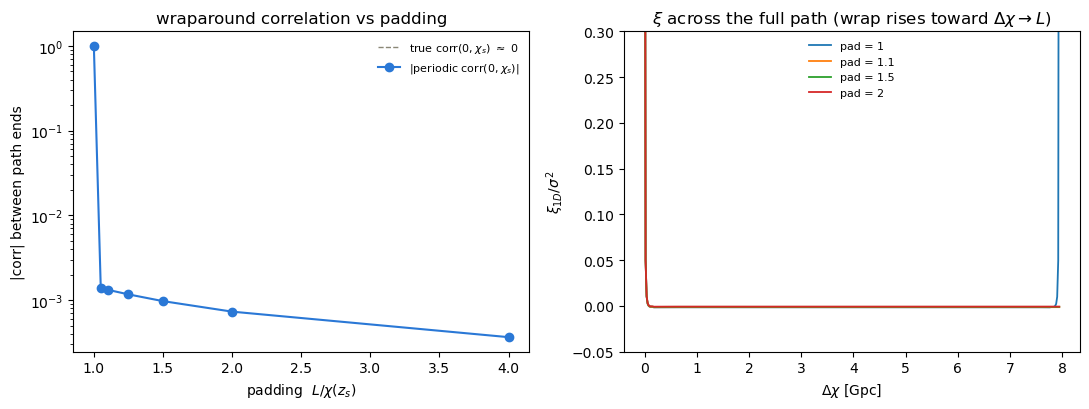

 pad     N_modes   corr(0, chi_s)    sigma2_disc/cont
 1.00      6322       +1.00000      0.9869
 1.05      6638       -0.00140      0.9870
 1.10      6954       -0.00132      0.9870
 1.25      7902       -0.00117      0.9872
 1.50      9483       -0.00097      0.9874
 2.00     12643       -0.00073      0.9876
 4.00     25286       -0.00036      0.9880


In [45]:
xi_true_far = float(p.xi([chi_s])[0])     # ~0 (order 1e-3 * sigma^2)
rows, fig = [], plt.figure(figsize=(11, 4.2))
ax1, ax2 = fig.subplots(1, 2)
for pad in PAD_LIST:
    fp = Field1D(p, pad * chi_s)
    r_end = float(fp.xi_periodic([chi_s])[0] / fp.sigma2_disc)
    rows.append((pad, fp.N, r_end, fp.sigma2_disc / s2_cont))
    dd = np.linspace(1.0, chi_s, 400)
    if pad in (1.0, 1.1, 1.5, 2.0):
        ax2.plot(dd / 1e6, fp.xi_periodic(dd) / fp.sigma2_disc, lw=1.3,
                 label=f"pad = {pad:g}")
ax1.axhline(xi_true_far / s2_cont, color="#8a8776", ls="--", lw=1,
            label="true corr($0,\\chi_s$) $\\approx$ 0")
ax1.plot([r[0] for r in rows], [abs(r[2]) for r in rows], "o-",
         color="#2a78d6", label="|periodic corr($0,\\chi_s$)|")
ax1.set_yscale("log"); ax1.set_xlabel("padding  $L/\\chi(z_s)$")
ax1.set_ylabel("|corr| between path ends"); ax1.legend(fontsize=8, frameon=False)
ax1.set_title("wraparound correlation vs padding")
ax2.set_xlabel("$\\Delta\\chi$ [Gpc]"); ax2.set_ylabel("$\\xi_{1D}/\\sigma^2$")
ax2.set_ylim(-0.05, 0.3); ax2.legend(fontsize=8, frameon=False)
ax2.set_title("$\\xi$ across the full path (wrap rises toward $\\Delta\\chi\\to L$)")
plt.tight_layout(); plt.show()

print(" pad     N_modes   corr(0, chi_s)    sigma2_disc/cont")
for pad, N, r_end, s2r in rows:
    print(f" {pad:4.2f}   {N:7d}   {r_end:+12.5f}      {s2r:.4f}")

**Read-off:** pad = 1.0 is catastrophic by construction (corr $= +1$); already at pad = 1.05–1.1
the end-to-end correlation drops to the true level ($|{\rm corr}|\lesssim 10^{-3}$), because
$\xi_{\rm 1D}$ decays over tens of Mpc while the padding adds hundreds. Mode count (cost) grows
linearly with pad. **Recommendation: pad $\approx$ 1.25–2 with the low-$k$ deficit
$\sigma^2_{\rm disc}/\sigma^2_{\rm cont}$ quoted; there is no benefit beyond pad 2.**
One field per realization covers all $z_s$ if $L = {\rm pad}\times\chi(z_{s,\max})$.

## D. Grid-independence — the point of the redesign

Old model: each shell draws an INDEPENDENT $\delta$ with $\sigma(M_b(\Delta\chi))$; thinner shells
$\Rightarrow$ smaller $M_b$ $\Rightarrow$ wilder draws, without bound. New model: the shell reads
the segment-average of ONE field; thinner shells fluctuate more too (a point of a continuous field
fluctuates more than a segment average) **but saturate at the grid-independent point value**
$bD\,\sigma_{\rm 1D}(R_\perp)$ — that bound IS the continuum limit. Compare, per shell of width
$\Delta\chi = \chi_s/N_z$ (uniform proxy, $z=1$ illustrative bias): the environment std entering
the exponent, and the per-shell burst-delivered count fraction
$\mathbb E[\lambda\,\mathbb 1(\lambda>\Lambda)] = \Phi_c(\ln\Lambda/\sigma_b - \sigma_b/2)$
(the tail mechanism convicted in `docs/nz_bias_convergence_note.md`).

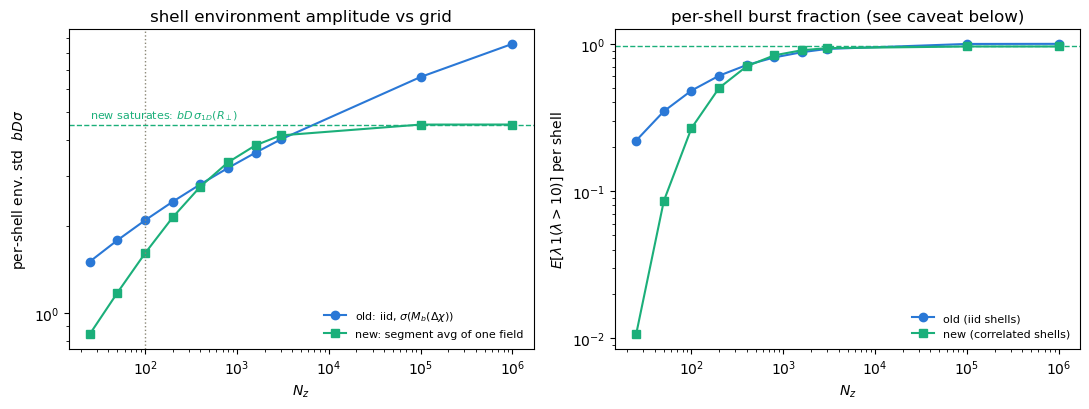

new-model saturation bD*sigma_1D = 4.516  (old model: unbounded, until the sigma(M) Mmin clamp)
 Nz    Dchi[Mpc]   sig_old   sig_new   burst_old   burst_new
   25     317.7     1.509     0.845   2.203e-01   1.064e-02
   50     158.9     1.791     1.177   3.480e-01   8.557e-02
  100      79.4     2.100     1.613   4.814e-01   2.674e-01
  200      39.7     2.437     2.150   6.077e-01   5.016e-01
  400      19.9     2.800     2.749   7.184e-01   7.044e-01
  800       9.9     3.191     3.337   8.089e-01   8.361e-01
 1600       5.0     3.608     3.827   8.781e-01   9.052e-01
 3000       2.6     4.008     4.140   9.236e-01   9.349e-01
100000       0.1     6.604     4.515   9.984e-01   9.597e-01
1000000       0.0     8.607     4.516   1.000e+00   9.598e-01


In [49]:
NZ_SCAN = np.array([25, 50, 100, 200, 400, 800, 1600, 3000,100000, 1000000])
Dchi = chi_s / NZ_SCAN
bD = C.Dg(1.0) * C.halobias(1.0, C.sigma_of_M(1e14))   # illustrative b*D at z=1
LAM = 10.0

# old: per-shell iid, sigma(M_b), M_b = 2 pi Rperp^2 Dchi rhoM0  (lensing.cpp:123)
Mb = 2.0 * np.pi * RPERP ** 2 * Dchi * C.rhoM0
sig_old = bD * C.sigma_of_M(Mb)
# new: segment-average of the shared field (same Rperp)
sig_new = bD * np.sqrt(p.sigma2_seg(Dchi))

burst = lambda s: Phic(np.log(LAM) / s - s / 2.0)
sat = bD * np.sqrt(s2_cont)          # the new model's Nz->inf bound (point value)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.loglog(NZ_SCAN, sig_old, "o-", color="#2a78d6", label="old: iid, $\\sigma(M_b(\\Delta\\chi))$")
ax1.loglog(NZ_SCAN, sig_new, "s-", color="#1baf7a", label="new: segment avg of one field")
ax1.axhline(sat, color="#1baf7a", ls="--", lw=1)
ax1.text(NZ_SCAN[0], sat * 1.05, "new saturates: $bD\\,\\sigma_{1D}(R_\\perp)$",
         fontsize=8, color="#1baf7a")
ax1.axvline(100, color="#8a8776", ls=":", lw=1)
ax1.set_xlabel("$N_z$"); ax1.set_ylabel("per-shell env. std  $b D \\sigma$")
ax1.set_title("shell environment amplitude vs grid"); ax1.legend(fontsize=8, frameon=False, loc="lower right")
ax2.loglog(NZ_SCAN, burst(sig_old), "o-", color="#2a78d6", label="old (iid shells)")
ax2.loglog(NZ_SCAN, burst(sig_new), "s-", color="#1baf7a", label="new (correlated shells)")
ax2.axhline(burst(sat), color="#1baf7a", ls="--", lw=1)
ax2.set_xlabel("$N_z$"); ax2.set_ylabel(f"$E[\\lambda\\,1(\\lambda>{LAM:g})]$ per shell")
ax2.set_title("per-shell burst fraction (see caveat below)")
ax2.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

print(f"new-model saturation bD*sigma_1D = {sat:.3f}  (old model: unbounded, "
      f"until the sigma(M) Mmin clamp)")
print(" Nz    Dchi[Mpc]   sig_old   sig_new   burst_old   burst_new")
for n, dc_, so, sn in zip(NZ_SCAN, Dchi, sig_old, sig_new):
    print(f"{n:5d}  {dc_/1e3:8.1f}   {so:7.3f}   {sn:7.3f}   {burst(so):.3e}   {burst(sn):.3e}")

**Read-off:** the old per-shell amplitude grows without bound as the grid refines (its only cap
is the numerical $\sigma(M)$ clamp at $M_{\min}$); the new one saturates at the grid-independent
$bD\,\sigma_{\rm 1D}(R_\perp)$. **Caveat on panel 2:** for the NEW model the per-shell burst
fraction saturating at a finite value is harmless — neighbouring shells' bursts are
*correlated* (one physical overdensity sampled many times), so the LOS-integrated statistics are
$N_z$-invariant by construction (§B: the sum over shells reproduces $\xi_{\rm 1D}$/$\sigma^2$
regardless of sampling). In the OLD model the bursts are *independent* per shell and stack
incoherently — that is the measured $f(\kappa>1)$ growth. The per-shell number is a mechanism
illustration; the decisive test is the MC acceptance rerun (next steps).

## E. Log-normal count layer

$\langle n\rangle = \bar n$ bookkeeping (exact in expectation for any $b\sigma$, but the SAMPLE
mean of a heavy log-normal converges slowly — quantified here), and the Agrawal+17 eq. (3.5)
caveat: with bias in the exponent, the count field's correlation is
$e^{b^2\xi_G}-1 \ne b^2\xi_G$ once $b^2\sigma^2 \sim 1$.

point sigma = 1.920;  shell-avg sigma (Dchi = 124 Mpc) = 0.561

 b*sig(point)   <lam> point    <lam> shell     [want 1.0000]
      0.3         1.0000        1.0000
      1.0         1.0005        1.0000
      2.0         1.0050        0.9999
      3.0         1.0354        0.9996


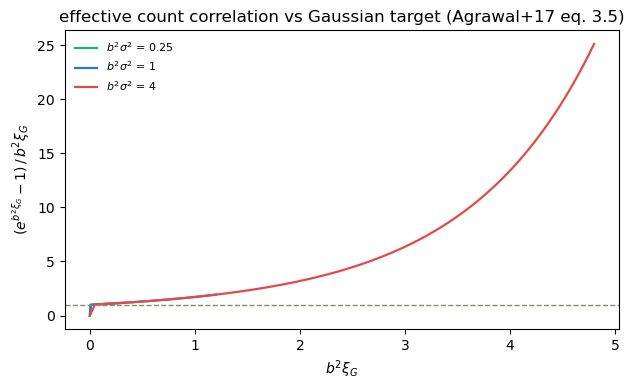

In [39]:
d1 = f.sample(rng, 2000).astype(np.float64)
ng1 = d1.shape[1]
nseg = 128
dseg = d1.reshape(2000, nseg, ng1 // nseg).mean(axis=2)   # shell averages
s2_pt, s2_sh = f.sigma2_disc, float(np.var(dseg))
print(f"point sigma = {np.sqrt(s2_pt):.3f};  shell-avg sigma "
      f"(Dchi = {f.L/nseg/1e3:.0f} Mpc) = {np.sqrt(s2_sh):.3f}")
print("\n b*sig(point)   <lam> point    <lam> shell     [want 1.0000]")
for bsig in (0.3, 1.0, 2.0, 3.0):
    b = bsig / np.sqrt(s2_pt)
    lam_p = lognormal_lambda(b, d1[:, ::64], s2_pt)
    lam_s = lognormal_lambda(b, dseg, s2_sh)
    print(f"   {bsig:6.1f}       {lam_p.mean():8.4f}      {lam_s.mean():8.4f}")

xi_g = np.linspace(0, 1.2, 100)
fig, ax = plt.subplots(figsize=(6.4, 4))
for b2s2, cc in ((0.25, "#1baf7a"), (1.0, "#2a78d6"), (4.0, "#e34948")):
    r = xi_g * b2s2
    ax.plot(r, (np.exp(r) - 1) / np.where(r == 0, 1, r), color=cc, lw=1.6,
            label=f"$b^2\\sigma^2$ = {b2s2:g}")
ax.axhline(1.0, color="#8a8776", ls="--", lw=1)
ax.set_xlabel("$b^2\\xi_G$"); ax.set_ylabel("$(e^{b^2\\xi_G}-1)\\,/\\,b^2\\xi_G$")
ax.set_title("effective count correlation vs Gaussian target (Agrawal+17 eq. 3.5)")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## Findings & open decisions

1. **The mode recipe works as written** on the whiteboard: $\sigma_n^2 = \frac{L}{2}P_{\rm 1D}(k_n)$
   per Re/Im component reproduces $\sigma_{\rm 1D}^2$ and $\xi_{\rm 1D}$ (§B); FFT $\equiv$ direct
   sum, so production can use `irfft` and sample shell centers by interpolation, or evaluate the
   direct sum at the (log-spaced) shell centers.
2. **Periodicity:** pad = 1 is maximally wrong (ends identical), pad $\ge$ 1.1 already fine;
   use pad 1.25–2 of $\chi(z_{s,\max})$. Cost is linear in pad. (§C)
3. **$R_\perp$ is THE model decision** — it sets the bounded point variance. $R_L$-floor
   territory gives $\sigma_{\rm 1D}\sim0.4$–1 for cluster masses. Sensitivity scan of final
   observables over $R_\perp \in [R_L(M_{\rm max})/2,\ 2R_L(M_{\rm max})]$ = the acceptance item. (§A)
4. **Grid-independence holds by construction** (§D): old amplitude diverges with $N_z$, new is
   bounded; the burst-fraction (tail) mechanism dies.
5. **Bookkeeping:** $\langle n\rangle=\bar n$ exact; the compensation term must use the variance
   of the $\delta$ actually used (point vs segment average — mind it in the C++ port). Sample-mean
   drift at $b\sigma\gtrsim2$ is heavy-tail sampling, not a bug. Effective bias exceeds $b$ once
   $b^2\sigma^2\sim1$ (known, accepted — item 3 of the 2026-07-15 discussion).

**Next steps:** wire the field into the cell tables (replace `sigma_old`/iid draw in
`bias_field_prototype.py` MC with segment reads of this field, all $j_M$ sharing it via
$b(M,z)$), rerun the $f(\kappa>1)$-vs-$N_z$ and $\kappa_{\rm thr}$-sweep acceptance, then take the
design + KP91/Agrawal references to the supervisor before any C++.